In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

print("Imported Successfully")

Imported Successfully


In [4]:
# !unzip data_2.zip

In [5]:
images = []
masks = []

image_path = "data/segmentation/images"
mask_path = "data/segmentation/masks"

image_files = sorted([f for f in os.listdir(image_path) if not f.startswith('.')])
mask_files = sorted([f for f in os.listdir(mask_path) if not f.startswith('.')])

if len(image_files) != len(mask_files):
    print(f" Warning: Mismatch in counts! Images: {len(image_files)}, Masks: {len(mask_files)}")

for img_file, mask_file in zip(image_files, mask_files):

    full_img_path = os.path.join(image_path, img_file)
    full_mask_path = os.path.join(mask_path, mask_file)

    img = cv2.imread(full_img_path)
    mask = cv2.imread(full_mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Skipping: Could not load image file -> {img_file}")
        continue
    if mask is None:
        print(f"Skipping: Could not load mask file -> {mask_file}")
        continue

    img = cv2.resize(img, (128,128))
    mask = cv2.resize(mask, (128,128))

    images.append(img)
    masks.append(mask)

X = np.array(images) / 255.0
y = np.array(masks) / 255.0

y = np.expand_dims(y, axis=-1)

print("Images shape (X):", X.shape)
print("Masks shape (y):", y.shape)

Images shape (X): (20, 128, 128, 3)
Masks shape (y): (20, 128, 128, 1)


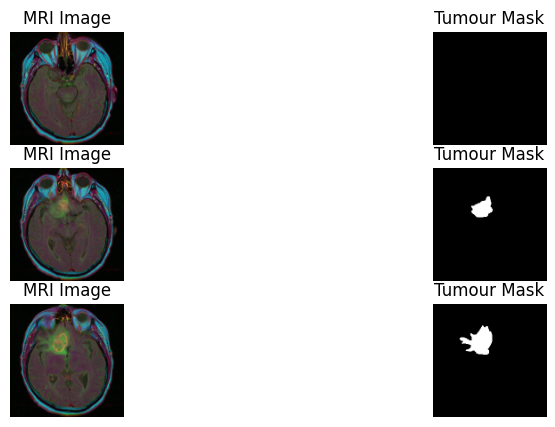

In [6]:
plt.figure(figsize=(10,5))

for i in range(3):

    plt.subplot(3,2,2*i+1)
    plt.imshow(X[i])
    plt.title("MRI Image")
    plt.axis("off")

    plt.subplot(3,2,2*i+2)
    plt.imshow(y[i].squeeze(), cmap='gray')
    plt.title("Tumour Mask")
    plt.axis("off")

plt.show()

In [7]:
inputs = Input((128,128,3))

# Encoder
c1 = Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(32, (3,3), activation='relu', padding='same')(p1)
p2 = MaxPooling2D((2,2))(c2)

# Bottleneck
b1 = Conv2D(64, (3,3), activation='relu', padding='same')(p2)

# Decoder
u1 = UpSampling2D((2,2))(b1)
merge1 = Concatenate()([u1, c2])
c3 = Conv2D(32, (3,3), activation='relu', padding='same')(merge1)

u2 = UpSampling2D((2,2))(c3)
merge2 = Concatenate()([u2, c1])
c4 = Conv2D(16, (3,3), activation='relu', padding='same')(merge2)

outputs = Conv2D(1, (1,1), activation='sigmoid')(c4)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │         17 │ conv2d_4[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,209 (227.38 KB)

 Trainable params: 58,209 (227.38 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test_val, y_test_val),
    epochs=15
)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9770 - loss: 0.2159 - val_accuracy: 0.9691 - val_loss: 0.2098
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9770 - loss: 0.1918 - val_accuracy: 0.9691 - val_loss: 0.1845
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9770 - loss: 0.1691 - val_accuracy: 0.9691 - val_loss: 0.1616
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9770 - loss: 0.1484 - val_accuracy: 0.9691 - val_loss: 0.1417
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9770 - loss: 0.1302 - val_accuracy: 0.9691 - val_loss: 0.1251
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9770 - loss: 0.1149 - val_accuracy: 0.9691 - val_loss: 0.1122
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9770 - loss: 0.1025 - val_accuracy: 0.9691 - val_loss: 0.1022
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9770 - loss: 0.0927 - val_accuracy: 0.9691 - val_loss: 0.0944
Epoch 9/15
1/1 ━

In [12]:
prediction = model.predict(
    np.expand_dims(X_test[2], axis=0)
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


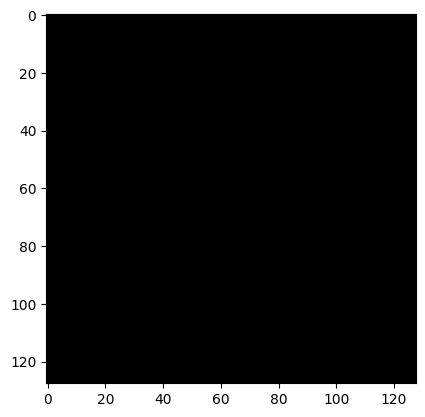

In [14]:
binary_prediction = (prediction.squeeze() > 0.5).astype(int)

# Use this binary prediction in your plot
plt.imshow(binary_prediction, cmap='gray')

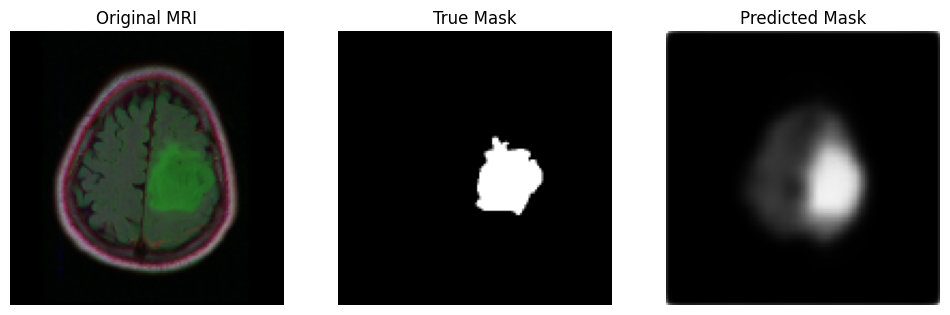

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_test[2])
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(y_test[2].squeeze(), cmap='gray')
plt.title("True Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction.squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()